In [1]:
# --- セル 1: ライブラリのインポートと設定 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 機械学習モデル
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# 評価・前処理
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# 日本語フォントの設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# 警告を無視（きれいな出力のため）
import warnings
warnings.filterwarnings('ignore')

print("ライブラリの読み込みが完了しました。")

ライブラリの読み込みが完了しました。


In [2]:
# --- セル 2: 設定とデータ前処理関数 ---

# === 設定セクション ===
CORPUS_PATH = 'dataset/narou_dataset.csv' # データセットのパス
TARGET_GENRE = 306
NUM_SAMPLES = 150000
# =====================

genres_map = {
    0: '未設定', 101: '異世界（恋愛）', 102: '現実世界（恋愛）', 201: 'ハイファンタジー', 202: 'ローファンタジー',
    301: '純文学', 302: 'ヒューマンドラマ', 303: '歴史', 304: '推理', 305: 'ホラー',
    306: 'アクション', 307: 'コメディー', 401: 'VRゲーム', 402: '宇宙', 403: '空想科学',
    404: 'パニック', 9901: '童話', 9902: '詩', 9903: 'エッセイ', 9904: 'リプレイ',
    9999: 'その他', 9801: 'ノンジャンル'
}

def load_and_preprocess(file_path, target_genre=None):
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイルが見つかりません - {file_path}")
        return None

    # 1. ジャンル絞り込み
    if target_genre is not None:
        if target_genre in genres_map:
            print(f"--- ジャンル: {genres_map[target_genre]} ({target_genre}) を抽出 ---")
            df = df[df['作品ジャンル'] == target_genre].copy()
        else:
            print("指定されたジャンルが存在しません。")
            return None
    else:
        print("--- 全ジャンルを対象 ---")

    # 2. 最低限のフィルタリング（短編などを除外）
    initial_len = len(df)
    df = df[df['投稿話数'] > 5]
    print(f"フィルタリング: {initial_len}件 -> {len(df)}件 (話数<5を除外)")

    # 3. 特徴量エンジニアリング
    # 日付変換
    df['初回投稿日'] = pd.to_datetime(df['初回投稿日'])
    df['最終更新日'] = pd.to_datetime(df['最終更新日'])
    min_date = df['初回投稿日'].min()

    # 数値特徴量の作成
    df['経過日数'] = (df['最終更新日'] - df['初回投稿日']).dt.days
    # ゼロ除算を防ぐため、投稿話数が0の場合は1として扱う（フィルタリング済みだが念のため）
    df['更新頻度'] = df['経過日数'] / df['投稿話数'].replace(0, 1)
    
    # 経過月数（トレンド用）
    df['初回投稿_年月'] = (df['初回投稿日'].dt.year - min_date.year) * 12 + (df['初回投稿日'].dt.month - min_date.month)
    
    # 4. 不要な列の削除
    drop_cols = [
        'タイトル', 'Nコード', '作者', 'あらすじ', 'キーワード',
        '初回投稿日', '最終更新日', 'is_eternal', '小説タイプ', '完結フラグ', '作品ジャンル'
    ]
    # ターゲット変数
    y = df['is_eternal']
    # 特徴量からターゲットと不要列を削除
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    # 5. 欠損値処理 (線形モデルなどはNaNでエラーになるため0埋め)
    X = X.fillna(0)
    
    # メタデータ(分析用にNコードなどを保持)
    meta_df = df[['Nコード', 'タイトル', 'is_eternal']].copy()
    
    return X, y, meta_df

print("関数定義完了。")

関数定義完了。


In [3]:
# --- セル 3: サンプリング関数 ---

def perform_sampling(X, y, meta_df, num_samples):
    if num_samples <= 0:
        return X, y, meta_df
    
    data = pd.concat([X, meta_df], axis=1)
    
    class_0 = data[data['is_eternal'] == 0]
    class_1 = data[data['is_eternal'] == 1]
    
    n_samples = min(num_samples, len(class_0), len(class_1))
    
    if n_samples == 0:
        print("エラー: データが足りません。")
        return None, None, None
        
    sampled_0 = class_0.sample(n=n_samples, random_state=42)
    sampled_1 = class_1.sample(n=n_samples, random_state=42)
    
    balanced_data = pd.concat([sampled_0, sampled_1]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 再分割
    y_res = balanced_data['is_eternal']
    meta_res = balanced_data[['Nコード', 'タイトル', 'is_eternal']]
    # 元の特徴量カラムだけを取り出す
    X_res = balanced_data[X.columns]
    
    print(f"サンプリング後の合計データ数: {len(X_res)}件 (各クラス {n_samples} 件)")
    return X_res, y_res, meta_res

In [4]:
# --- セル 4: 学習と評価の実行 (分布分析用データ保存版) ---
import sys

# データのロード
loaded_data = load_and_preprocess(CORPUS_PATH, TARGET_GENRE)

if loaded_data is None:
    print("\n【重要】データの読み込みに失敗しました。")
    raise ValueError("データ読み込みエラーのため終了します。")

X, y, meta = loaded_data
X, y, meta = perform_sampling(X, y, meta, NUM_SAMPLES)

# === モデルの定義 ===
models = {
    # LightGBMとRandomForestはCPU (n_jobs=-1 で全コア使用)
    'LightGBM': lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, verbose=-1, random_state=42, n_jobs=-1),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=1000, learning_rate=0.05, random_state=42, eval_metric='logloss', early_stopping_rounds=50, n_jobs=-1),
    
    # 非決定木ベース
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'SVM': SVC(probability=True, random_state=42),
    'MLP (NeuralNet)': MLPClassifier(max_iter=1000, random_state=42),
    'k-NN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

# 結果格納用
results = []
feature_importances = pd.DataFrame(index=X.columns)
val_predictions = []

# 交差検証 (5-Fold)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n=== モデル学習開始 ===")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n--- Fold {fold+1}/5 ---")
    
    X_train_raw, X_val_raw = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    meta_val = meta.iloc[val_idx]
    
    # 標準化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_val_scaled = scaler.transform(X_val_raw)
    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)

    for name, model in models.items():
        if name in ['LightGBM', 'RandomForest', 'XGBoost']:
            X_tr, X_va = X_train_raw, X_val_raw
        else:
            X_tr, X_va = X_train_scaled, X_val_scaled
        
        # 学習
        print(f"  Training {name}...", end="\r")
        if name == 'LightGBM':
            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
        elif name == 'XGBoost':
            model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)
        else:
            model.fit(X_tr, y_train)
        
        # 予測
        pred = model.predict(X_va)
        
        acc = accuracy_score(y_val, pred)
        prec = precision_score(y_val, pred, zero_division=0)
        rec = recall_score(y_val, pred, zero_division=0)
        f1 = f1_score(y_val, pred, zero_division=0)
        
        results.append({
            'Model': name, 'Fold': fold+1,
            'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1
        })
        
        if hasattr(model, 'feature_importances_'):
            feature_importances[f'{name}_fold{fold+1}'] = model.feature_importances_
            
        if name == 'LightGBM':
            proba = model.predict_proba(X_va)[:, 1]
            # メタデータ + 特徴量 + 予測結果 を結合
            fold_res = pd.concat([meta_val.reset_index(drop=True), X_val_raw.reset_index(drop=True)], axis=1)
            fold_res['proba_1'] = proba
            fold_res['true_label'] = y_val.values
            val_predictions.append(fold_res)

print("\n全学習完了。")

--- ジャンル: アクション (306) を抽出 ---
フィルタリング: 16461件 -> 6914件 (話数<5を除外)
サンプリング後の合計データ数: 5420件 (各クラス 2710 件)

=== モデル学習開始 ===

--- Fold 1/5 ---
  Training k-NN...uralNet)......
--- Fold 2/5 ---


  File "c:\Users\blast\miniconda3\envs\torch311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\blast\miniconda3\envs\torch311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\blast\miniconda3\envs\torch311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\blast\miniconda3\envs\torch311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  Training k-NN...uralNet)......
--- Fold 3/5 ---
  Training k-NN...uralNet)......
--- Fold 4/5 ---
  Training k-NN...uralNet)......
--- Fold 5/5 ---
  Training k-NN...uralNet)......
全学習完了。



=== モデル別平均スコア (F1スコア降順) ===
| Model              |   Accuracy |   Precision |   Recall |   F1 Score |
|:-------------------|-----------:|------------:|---------:|-----------:|
| XGBoost            |     0.7611 |      0.7720 |   0.7413 |     0.7563 |
| LightGBM           |     0.7583 |      0.7674 |   0.7417 |     0.7542 |
| RandomForest       |     0.7541 |      0.7693 |   0.7262 |     0.7470 |
| MLP (NeuralNet)    |     0.7463 |      0.7558 |   0.7288 |     0.7415 |
| SVM                |     0.7186 |      0.7395 |   0.6756 |     0.7058 |
| k-NN               |     0.6876 |      0.6918 |   0.6771 |     0.6842 |
| LogisticRegression |     0.6528 |      0.6350 |   0.7192 |     0.6743 |


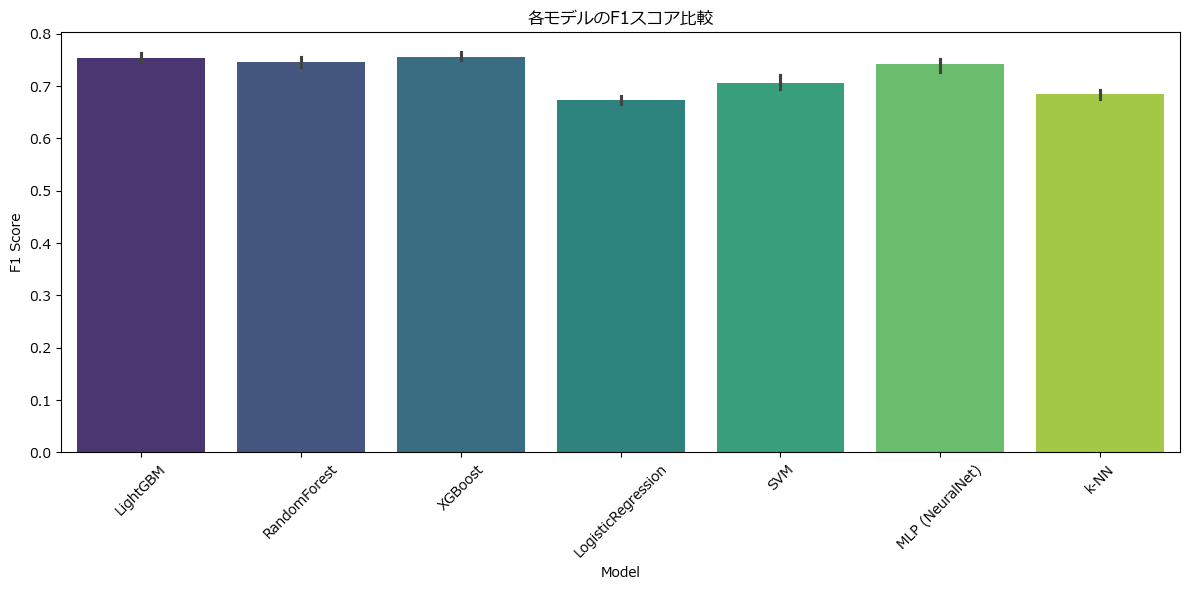

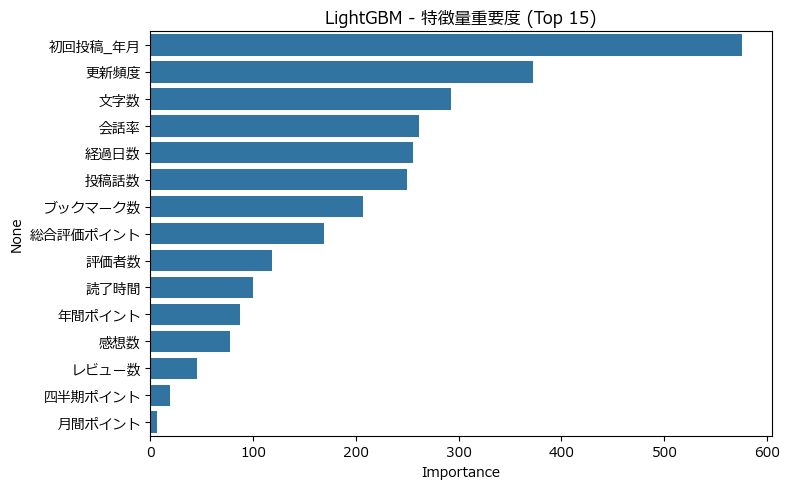

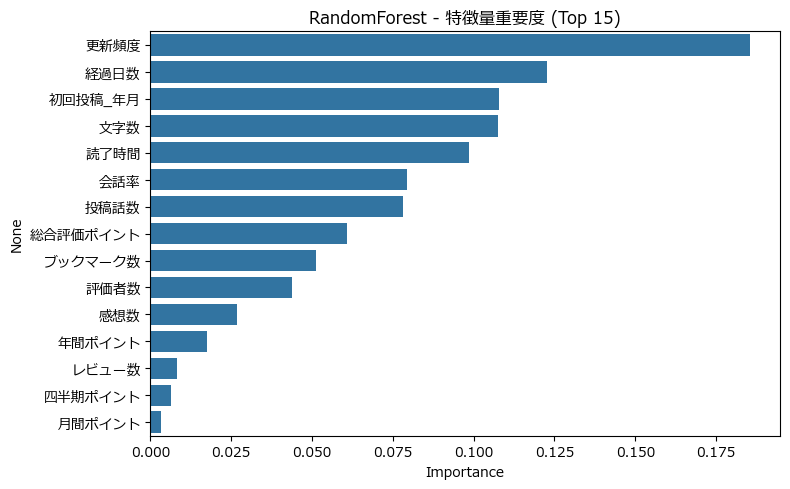

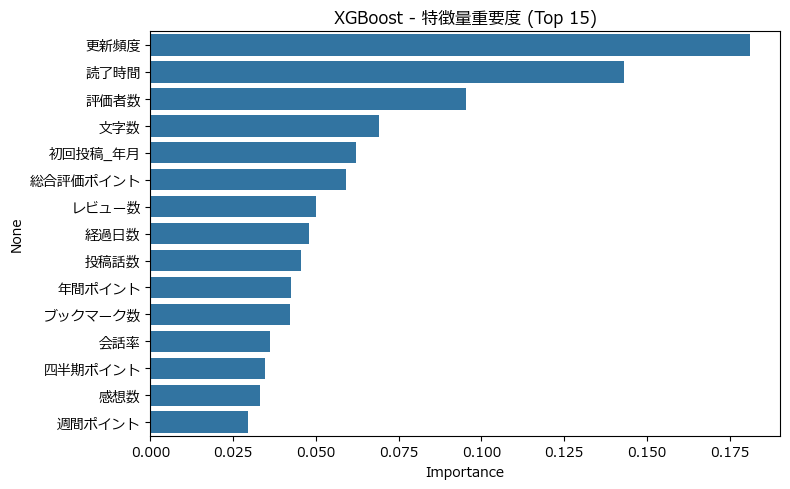

In [5]:
# --- セル 5: 結果の集計と可視化 ---

df_results = pd.DataFrame(results)
# モデルごとの平均スコアを算出
summary = df_results.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].mean().sort_values('F1 Score', ascending=False)

print("\n=== モデル別平均スコア (F1スコア降順) ===")
print(summary.to_markdown(floatfmt=".4f"))

# スコア比較のグラフ
plt.figure(figsize=(12, 6))
sns.barplot(x=df_results['Model'], y=df_results['F1 Score'], hue=df_results['Model'], palette='viridis', legend=False)
plt.title('各モデルのF1スコア比較')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 特徴量重要度 (決定木系モデルのみ)
tree_models = ['LightGBM', 'RandomForest', 'XGBoost']
for model_name in tree_models:
    cols = [c for c in feature_importances.columns if model_name in c]
    if not cols: continue
    
    # 各Foldの平均をとる
    feature_importances[f'{model_name}_mean'] = feature_importances[cols].mean(axis=1)
    sorted_imp = feature_importances.sort_values(f'{model_name}_mean', ascending=False).head(15)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=sorted_imp[f'{model_name}_mean'], y=sorted_imp.index)
    plt.title(f'{model_name} - 特徴量重要度 (Top 15)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

=== 誤分類の傾向分析 ===
データ総数: 5420件
・偽陽性 (完結なのにエタる判定): 261件
・偽陰性 (エタりなのに完結判定): 349件


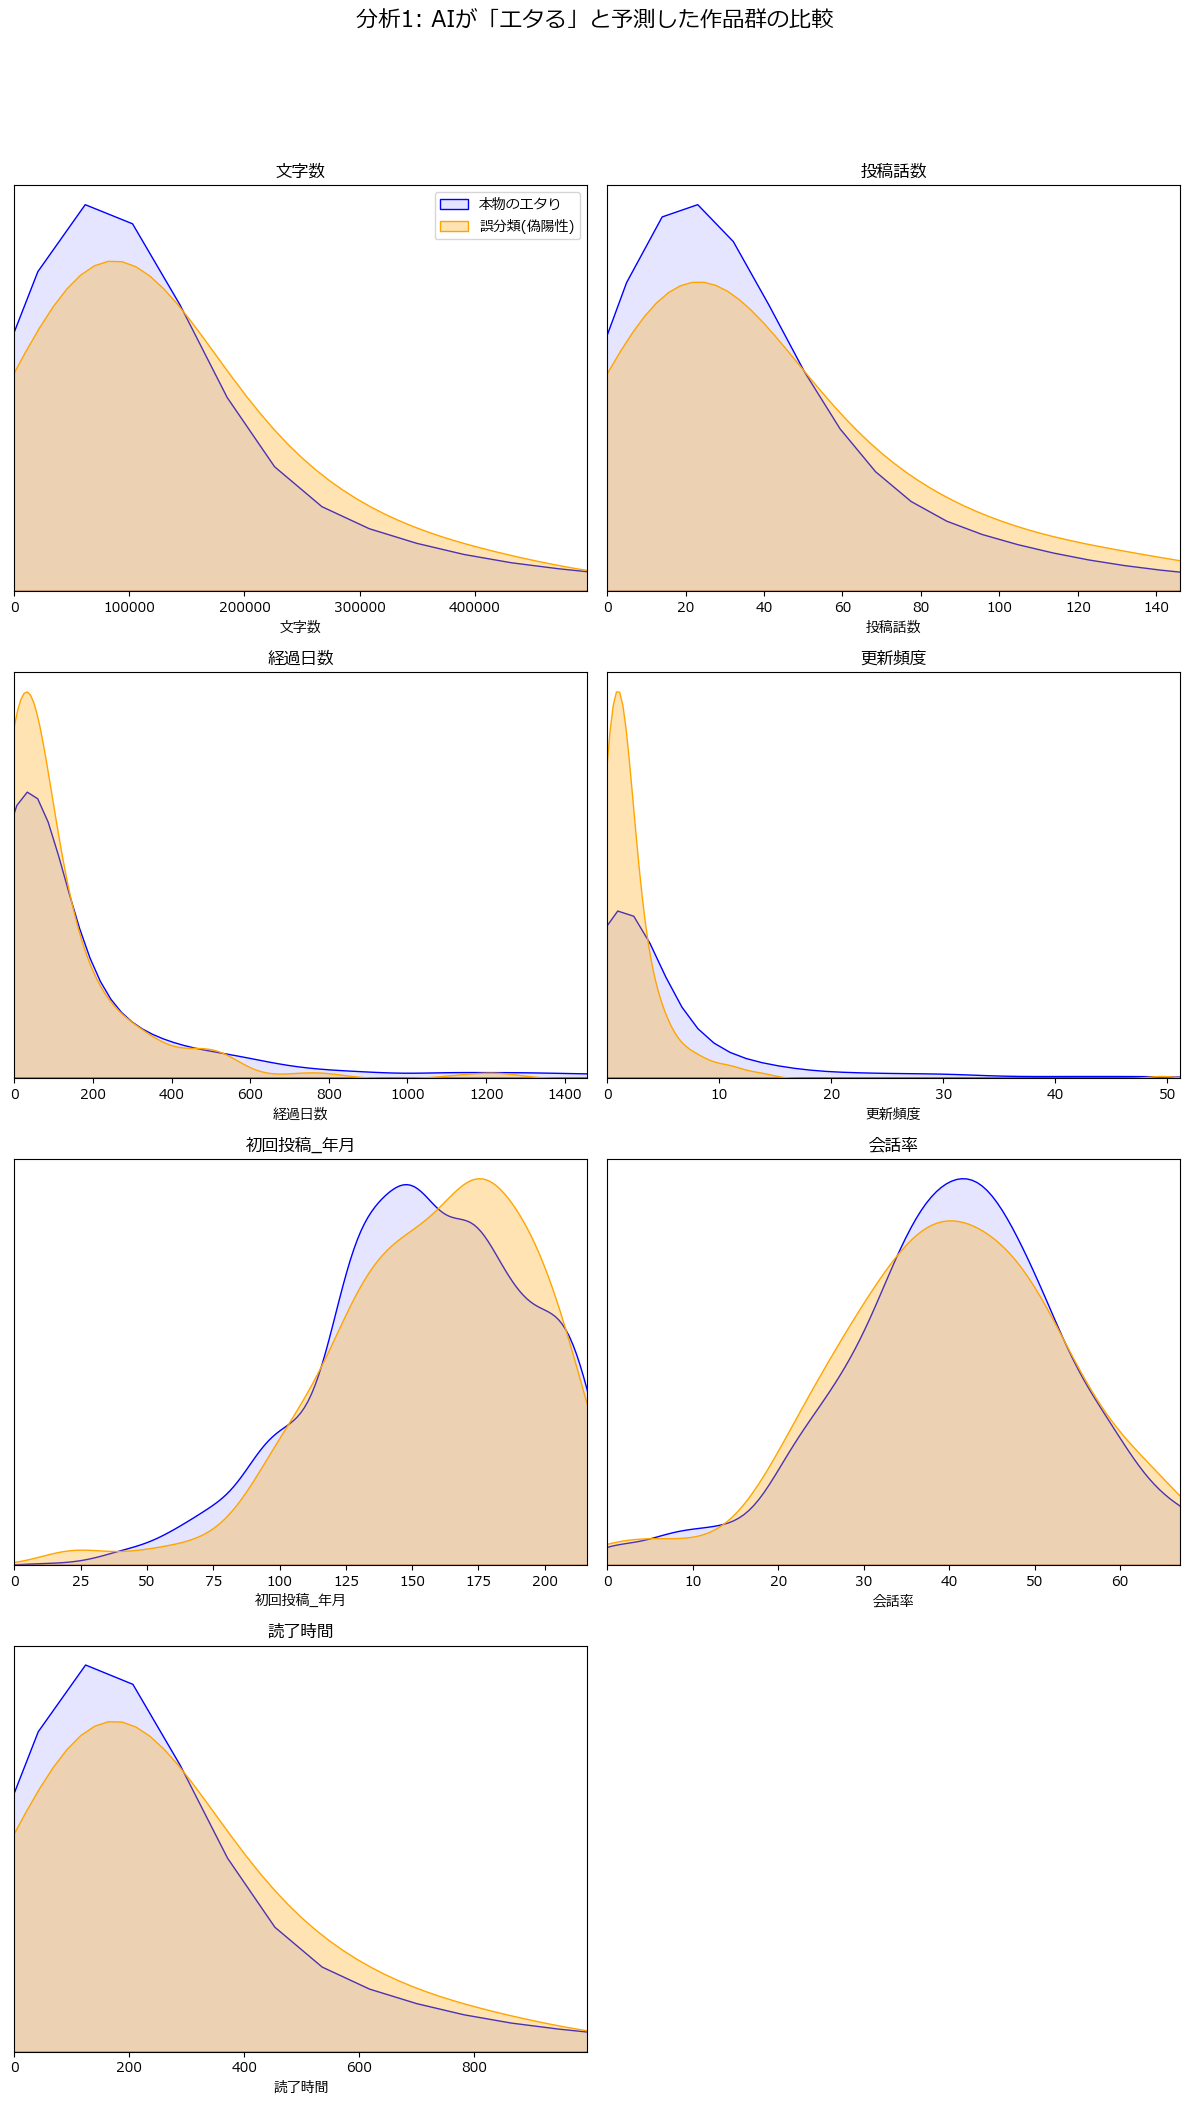

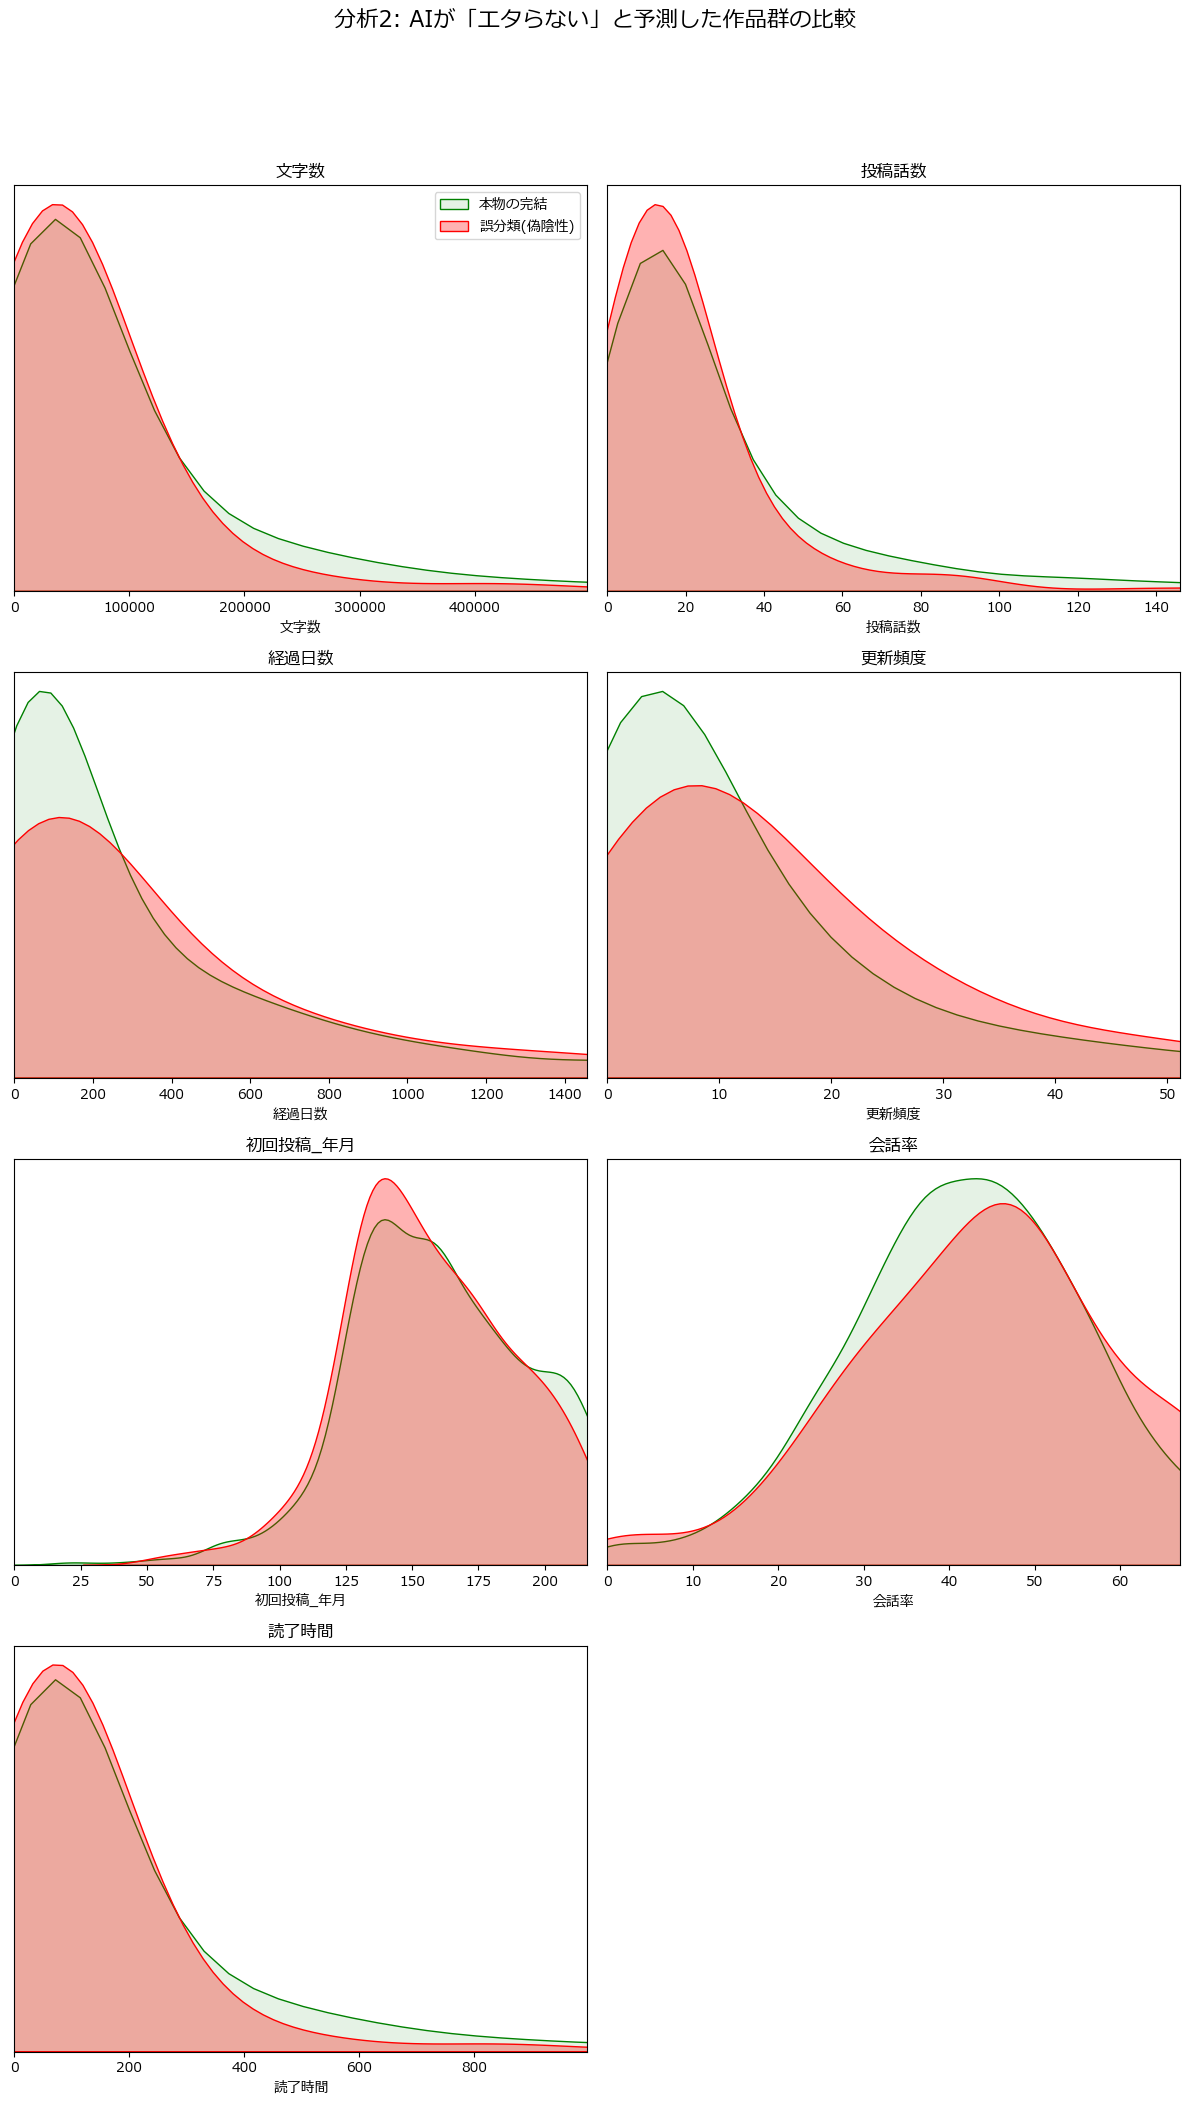

In [6]:
# --- セル 6: 特徴量分布の比較分析 (双方向の誤分類分析) ---
import matplotlib.pyplot as plt
import seaborn as sns

if val_predictions:
    df_pred_all = pd.concat(val_predictions, ignore_index=True)
    
    # === データセットの定義 ===
    # 1. 実際にエタっている作品 (True Label = 1)
    actual_eternal = df_pred_all[df_pred_all['true_label'] == 1]
    
    # 2. 実際にエタっていない作品 (True Label = 0)
    actual_non_eternal = df_pred_all[df_pred_all['true_label'] == 0]
    
    # 3. 偽陽性 (False Positive): 実際は0だが、AIが強く1(エタる)と予測
    #    → 「完結作品なのに、なぜエタると思われた？」
    false_positive = df_pred_all[(df_pred_all['true_label'] == 0) & (df_pred_all['proba_1'] > 0.7)]
    
    # 4. 偽陰性 (False Negative): 実際は1だが、AIが強く0(エタらない)と予測
    #    → 「エタり作品なのに、なぜ順調だと思われた？」
    false_negative = df_pred_all[(df_pred_all['true_label'] == 1) & (df_pred_all['proba_1'] < 0.3)]
    
    # 分析対象とする数値特徴量
    target_features = ['文字数', '投稿話数', '経過日数', '更新頻度', '初回投稿_年月', '会話率', '読了時間']
    features_to_plot = [col for col in target_features if col in df_pred_all.columns]

    print(f"=== 誤分類の傾向分析 ===")
    print(f"データ総数: {len(df_pred_all)}件")
    print(f"・偽陽性 (完結なのにエタる判定): {len(false_positive)}件")
    print(f"・偽陰性 (エタりなのに完結判定): {len(false_negative)}件")

    # --- グラフ1: 「AIが『エタる』と判断した群」の比較 ---
    # 目的: 誤分類された完結作品(FP)は、本物のエタり作品(TP)と何が似ていたのか？
    fig1 = plt.figure(figsize=(12, 20))
    fig1.suptitle('分析1: AIが「エタる」と予測した作品群の比較', fontsize=16, y=1.05)
    
    for i, feature in enumerate(features_to_plot):
        plt.subplot(4, 2, i+1)
        # 本物のエタり (青)
        sns.kdeplot(actual_eternal[feature], color='blue', label='本物のエタり', fill=True, alpha=0.1)
        # エタると間違われた完結作品 (オレンジ)
        sns.kdeplot(false_positive[feature], color='orange', label='誤分類(偽陽性)', fill=True, alpha=0.3)
        
        plt.title(feature)
        # 外れ値対策（表示範囲の制限）
        plt.xlim(0, df_pred_all[feature].quantile(0.95))
        if i == 0: plt.legend() # 凡例は最初のグラフだけ
        plt.ylabel('')
        plt.yticks([]) # Y軸の数値は消す（形状比較のため）

    plt.tight_layout()
    plt.show()

    print("\n" + "="*80 + "\n")

    # --- グラフ2: 「AIが『エタらない』と判断した群」の比較 ---
    # 目的: 誤分類されたエタり作品(FN)は、本物の完結作品(TN)と何が似ていたのか？
    fig2 = plt.figure(figsize=(12, 20))
    fig2.suptitle('分析2: AIが「エタらない」と予測した作品群の比較', fontsize=16, y=1.05)
    
    for i, feature in enumerate(features_to_plot):
        plt.subplot(4, 2, i+1)
        # 本物の完結・継続 (緑)
        sns.kdeplot(actual_non_eternal[feature], color='green', label='本物の完結', fill=True, alpha=0.1)
        # 完結すると間違われたエタり作品 (赤)
        sns.kdeplot(false_negative[feature], color='red', label='誤分類(偽陰性)', fill=True, alpha=0.3)
        
        plt.title(feature)
        plt.xlim(0, df_pred_all[feature].quantile(0.95))
        if i == 0: plt.legend()
        plt.ylabel('')
        plt.yticks([])

    plt.tight_layout()
    plt.show()

else:
    print("予測結果データがありません。セル4を実行してください。")